<div style="text-align: right; font-weight: bold;">
東京工科大学コンピュータサイエンス学部<br>
福西広晃
</div>

----

# 画像検索の概要

- 画像検索では、複数の画像の中から、**特定の対象が写っている画像を自動的に見つける**処理を行う。

- 今回は、Google Driveに保存されている複数のjpg画像を読み込み、AIを利用して画像の内容を判定する。

- 最初に、指定したフォルダ内の**すべてのjpg画像を読み込み、画像を確認する**。

- 次に、学習済みの画像分類モデルを利用して、読み込んだ画像の中から**猫が写っている画像を検出する**。
  - 猫と判定された画像を抽出する
  - 判定された種類を表示する
  - 判定の確率を表示する

- さらに、物体検出モデルを利用して、読み込んだ画像の中から**人が写っている画像を検出する**。
  - 人が写っている画像を抽出する
  - 画像内に写っている**人数を数える**
  - 検出結果と人数を表示する

- 本演習では、次の流れで画像データを分析する。
  1. **画像データの読み込み**
  2. **猫の画像を検出**
  3. **人の画像を検出**
  4. **画像内の人数を集計**

- このように、AIを利用することで、大量の画像を1枚ずつ人が確認しなくても、**画像の内容に基づいて必要な画像を自動的に検索・抽出することができる**。

# データの読み込み

**プロンプトの例**<br>
「データフォルダの中の画像フォルダに入っているjpgファイルを全て読み込んで、表示してください。」

# 猫の画像を検出

**プロンプトの例**<br>
「読み込み済みの画像ファイルから猫の画像を検出し、表示してください。画像検出には機械学習モデルを使用してください。」

# 人の画像を検出

**プロンプトの例**<br>
「読み込み済みの画像ファイルから人の画像を検出し、表示してください。また、そのなかに含まれる人の数を表示してください。画像検出には機械学習モデルを使用してください。」

----
----
----
----
----
----
----
----
----
----

# プログラム例

## データの読み込み

Searching for .jpg files in: ../データ/画像
Found 10 image files. Displaying them now...
Displaying: 01_大学生.jpg


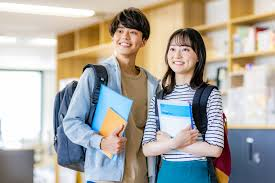

Displaying: 02_大学生.jpg


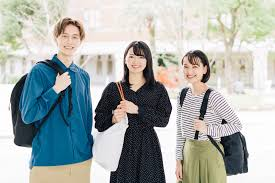

Displaying: 03_大学生.jpg


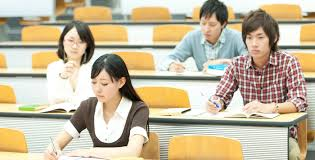

Displaying: 04_大学生.jpg


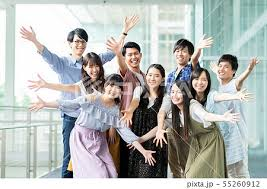

Displaying: 05_大学生.jpg


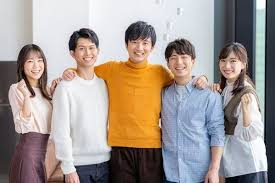

Displaying: 06_動物.jpg


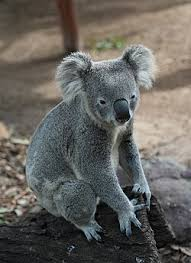

Displaying: 07_動物.jpg


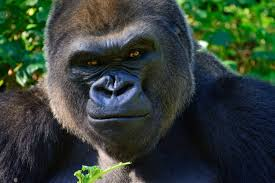

Displaying: 08_動物.jpg


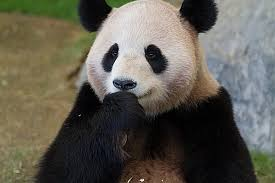

Displaying: 09_動物.jpg


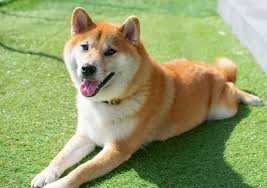

Displaying: 10_動物.jpg


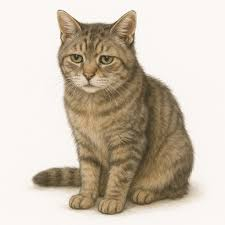

In [1]:
import os
import glob
from PIL import Image

# ローカルのデータフォルダパス
folder_path = '../データ/画像'

print(f"Searching for .jpg files in: {folder_path}")

# フォルダが存在するか確認
if not os.path.exists(folder_path):
    print(
        f"Error: The folder '{folder_path}' does not exist. "
        "Please check the path."
    )
    jpg_files = []

else:
    # jpgファイルを取得
    jpg_files = glob.glob(
        os.path.join(folder_path, '*.jpg')
    )
    
    # JPEGファイルも対象にする
    jpg_files += glob.glob(
        os.path.join(folder_path, '*.jpeg')
    )

    if not jpg_files:
        print("No .jpg files found in the specified folder.")

    else:
        print(
            f"Found {len(jpg_files)} image files. "
            "Displaying them now..."
        )

        # 取得した画像を表示
        for file_path in jpg_files:
            try:
                print(
                    f"Displaying: {os.path.basename(file_path)}"
                )

                img = Image.open(file_path)
                display(img)

            except Exception as e:
                print(
                    f"Could not open or display "
                    f"{file_path}: {e}"
                )


# 猫の画像を検出

必要なライブラリをインストール中...
インストール完了

MobileNetV2モデルを読み込み中...
MobileNetV2モデルを読み込みました。

ImageNetクラスラベルを取得中...
クラスラベルを取得しました。

猫検出を実行しています...

猫と判定された画像：1枚



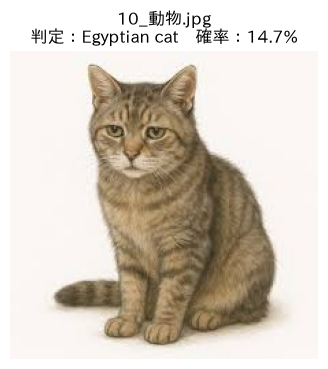

猫検出が完了しました。


In [2]:
import subprocess
import sys

print("必要なライブラリをインストール中...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torchvision"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "matplotlib_fontja"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pillow"])
print("インストール完了\n")

import os
import torch
import json
import urllib.request
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib_fontja
from torchvision import models, transforms

# 日本語表示を有効化
matplotlib_fontja.japanize()

# MobileNetV2モデルを読み込み
print("MobileNetV2モデルを読み込み中...")
model = models.mobilenet_v2(weights='DEFAULT')
model.eval()
print("MobileNetV2モデルを読み込みました。\n")

# 前処理パイプライン
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ImageNetのクラスラベルを取得
print("ImageNetクラスラベルを取得中...")
url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
with urllib.request.urlopen(url) as response:
    imagenet_classes = [line.decode('utf-8').strip() for line in response.readlines()]
print("クラスラベルを取得しました。\n")

print("猫検出を実行しています...\n")

cat_images = []

# jpg_filesはデータ読み込みセルから取得
for file_path in jpg_files:
    try:
        # 画像を読み込み
        img = Image.open(file_path).convert('RGB')
        
        # 前処理
        img_tensor = preprocess(img).unsqueeze(0)
        
        # 予測
        with torch.no_grad():
            predictions = model(img_tensor)
        
        # トップ5の予測を取得
        probabilities = torch.nn.functional.softmax(predictions[0], dim=0)
        top5_prob, top5_catid = torch.topk(probabilities, 5)
        
        # 猫関連のクラスを探す
        for i, catid in enumerate(top5_catid):
            catid_int = int(catid)
            if catid_int < len(imagenet_classes):
                class_name = imagenet_classes[catid_int]
                if 'cat' in class_name.lower():
                    probability = float(top5_prob[i])
                    cat_images.append(
                        (file_path, class_name, probability)
                    )
                    break
    
    except Exception as e:
        print(f"検出エラー（{os.path.basename(file_path)}）: {e}")

# 猫と判定された画像を表示
print(f"猫と判定された画像：{len(cat_images)}枚\n")

for file_path, label, probability in cat_images:
    
    img = Image.open(file_path)
    
    plt.figure(figsize=(5, 4))
    
    plt.imshow(img)
    plt.axis("off")
    
    plt.title(
        f"{os.path.basename(file_path)}\n"
        f"判定：{label}　確率：{probability:.1%}"
    )
    
    plt.show()

print("猫検出が完了しました。")


# 人の画像を検出

人物検出モデルを読み込みました。
10枚の画像を確認します。
人が写っている画像：5枚


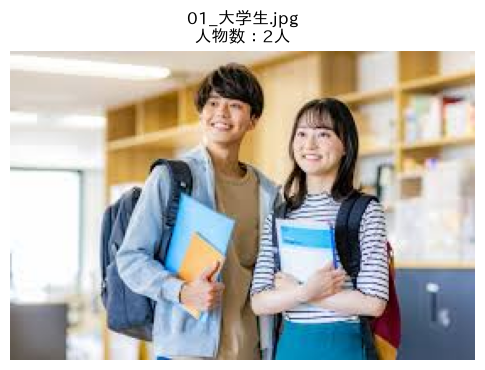

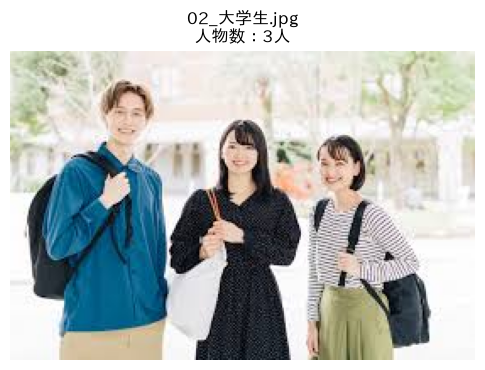

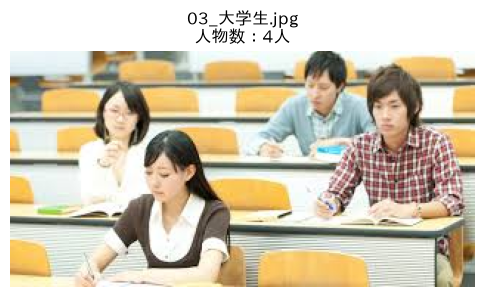

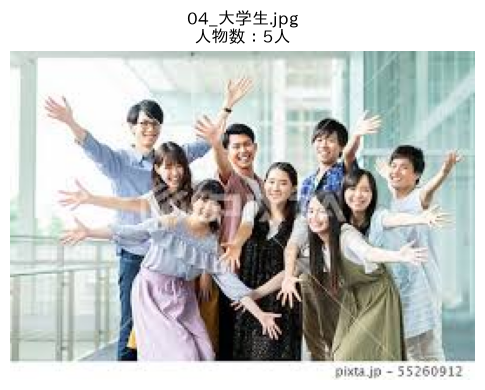

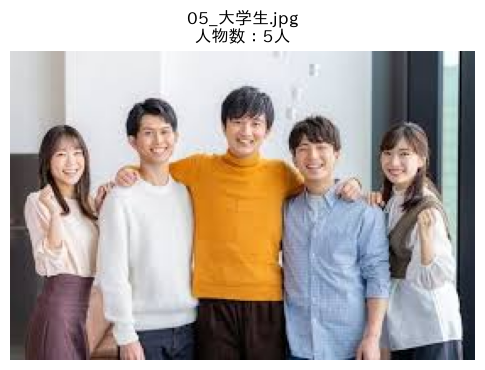

In [3]:
!pip install -q ultralytics

import os
import matplotlib.pyplot as plt
import matplotlib_fontja
from PIL import Image
from ultralytics import YOLO

# 日本語表示を有効化
matplotlib_fontja.japanize()

# -----------------------------
# 1. 人物検出モデルを読み込む
# -----------------------------
model = YOLO("yolo11n.pt")

print("人物検出モデルを読み込みました。")
print(f"{len(jpg_files)}枚の画像を確認します。")

# -----------------------------
# 2. 人が写っている画像を抽出
# -----------------------------
person_images = []

for file_path in jpg_files:

    # YOLOで物体検出
    results = model(
        file_path,
        conf=0.4,
        verbose=False
    )

    result = results[0]

    # 検出されたクラス番号を取得
    detected_classes = (
        result.boxes.cls
        .cpu()
        .numpy()
        .astype(int)
    )

    # YOLOでは class 0 が person
    person_count = int(
        (detected_classes == 0).sum()
    )

    # 人が1人以上写っている画像だけ保存
    if person_count > 0:
        person_images.append(
            (file_path, person_count)
        )

print(f"人が写っている画像：{len(person_images)}枚")

# -----------------------------
# 3. 人が写っている画像を表示
# -----------------------------
for file_path, person_count in person_images:

    image = Image.open(file_path)

    plt.figure(figsize=(6, 5))

    plt.imshow(image)
    plt.axis("off")

    plt.title(
        f"{os.path.basename(file_path)}\n"
        f"人物数：{person_count}人"
    )

    plt.show()